## 0. Setup

In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing  import StandardScaler
from sklearn.cluster        import KMeans
from sklearn.decomposition  import PCA, FactorAnalysis
from sklearn.metrics        import silhouette_score
from sklearn.linear_model   import Lasso, LassoCV, lasso_path, LinearRegression
from sklearn.model_selection import KFold

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi']   = 110
plt.rcParams['savefig.dpi']  = 150
plt.rcParams['savefig.bbox'] = 'tight'

FIGDIR = 'figures2'
os.makedirs(FIGDIR, exist_ok=True)
def savefig(name):
    plt.savefig(os.path.join(FIGDIR, name + '.pdf'))
    plt.savefig(os.path.join(FIGDIR, name + '.png'))


In [2]:
df = pd.read_csv('bike_sharing_hourly.csv')
df['dteday'] = pd.to_datetime(df['dteday'])

df['season_lbl']  = df['season'].map({1:'Winter',2:'Spring',3:'Summer',4:'Fall'})
df['weather_lbl'] = df['weathersit'].map({1:'Clear',2:'Mist',
                                          3:'Light rain',4:'Heavy rain'})
df['weekday_lbl'] = df['weekday'].map({0:'Sun',1:'Mon',2:'Tue',3:'Wed',
                                       4:'Thu',5:'Fri',6:'Sat'})
df['year_lbl']    = df['yr'].map({0:2011, 1:2012})
df['temp_c']   = df['temp']  * 41
df['hum_pct']  = df['hum']   * 100
df['wind_kmh'] = df['windspeed'] * 67

print('Shape:', df.shape, ' Missing:', df.isna().sum().sum())
df.head()


Shape: (17379, 25)  Missing: 0


   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp   atemp   hum  windspeed  casual  registered  cnt high_demand season_lbl weather_lbl weekday_lbl  year_lbl  temp_c  hum_pct  wind_kmh
0        1  2011-01-01       1   0     1   0        0        6           0           1  0.24  0.2879  0.81        0.0       3          13   16         Low     Winter       Clear         Sat      2011    9.84    81.00     0.000
1        2  2011-01-01       1   0     1   1        0        6           0           1  0.22  0.2727  0.80        0.0       8          32   40         Low     Winter       Clear         Sat      2011    9.02    80.00     0.000


## 1. exploratory data analysis


In [3]:
df[['cnt','casual','registered','temp','atemp','hum','windspeed']].describe().round(2)


            cnt    casual  registered      temp     atemp       hum  windspeed
count  17379.00  17379.00    17379.00  17379.00  17379.00  17379.00   17379.00
mean     189.46     35.68      153.79      0.50      0.48      0.63       0.19
std      181.39     49.31      151.36      0.19      0.17      0.19       0.12
min        1.00      0.00        0.00      0.02      0.00      0.00       0.00
25%       40.00      4.00       34.00      0.34      0.33      0.48       0.10
50%      142.00     17.00      115.00      0.50      0.48      0.63       0.19
75%      281.00     48.00      220.00      0.66      0.62      0.78       0.25
max      977.00    367.00      886.00      1.00      1.00      1.00       0.85


`cnt` ranges from 1 to 977 with mean $\approx 189$ and a
standard deviation $\approx 181$. By construction
`cnt = casual + registered`, so the two components must not enter as
predictors of `cnt`. `temp` and `atemp` look nearly identical.

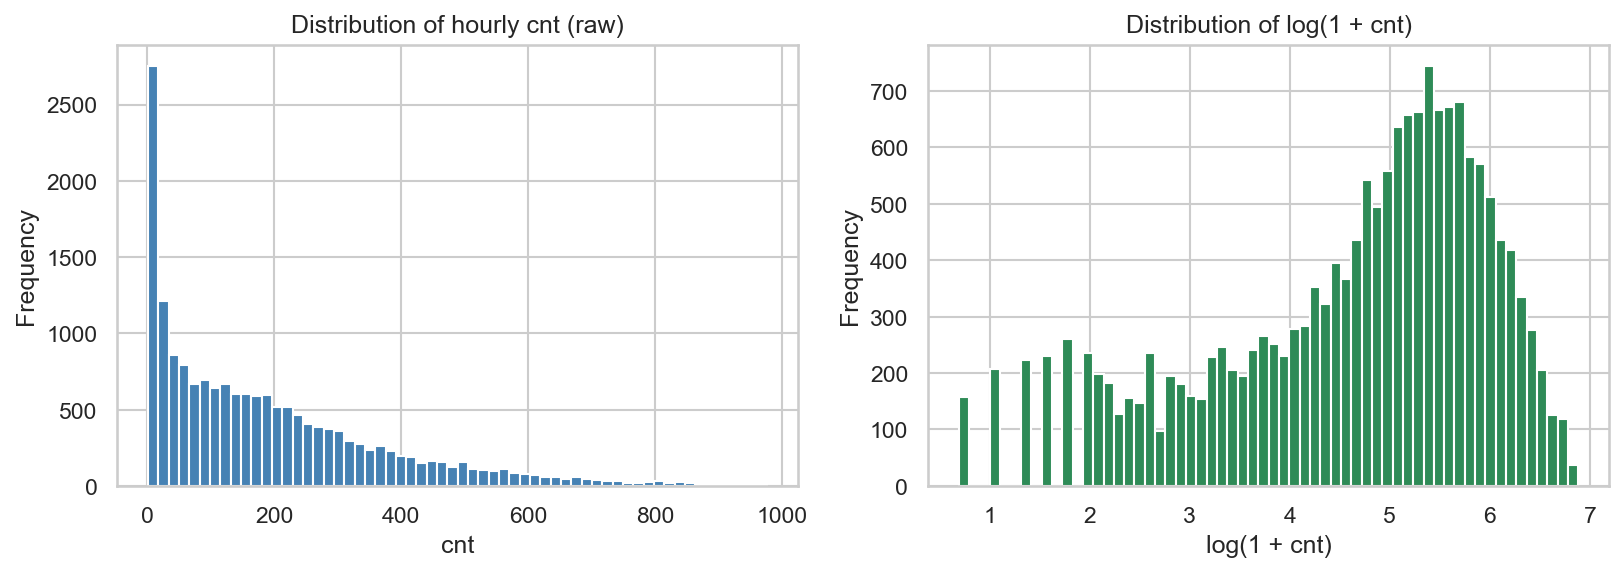

Skewness raw     : 1.277
Skewness log1p   : -0.818


In [4]:
from scipy import stats
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df['cnt'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('cnt'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of hourly cnt (raw)')

axes[1].hist(np.log1p(df['cnt']), bins=60, color='seagreen', edgecolor='white')
axes[1].set_xlabel('log(1 + cnt)'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of log(1 + cnt)')
plt.tight_layout(); savefig('fig01_cnt_distribution'); plt.show()

print(f'Skewness raw     : {stats.skew(df["cnt"]):.3f}')
print(f'Skewness log1p   : {stats.skew(np.log1p(df["cnt"])):.3f}')


Raw `cnt` is heavily right-skewed; $\log(1+\texttt{cnt})$ is
closer to symmetric but visibly *bimodal* --- the first hint of two
latent demand regimes (commuter vs.\ off-peak).

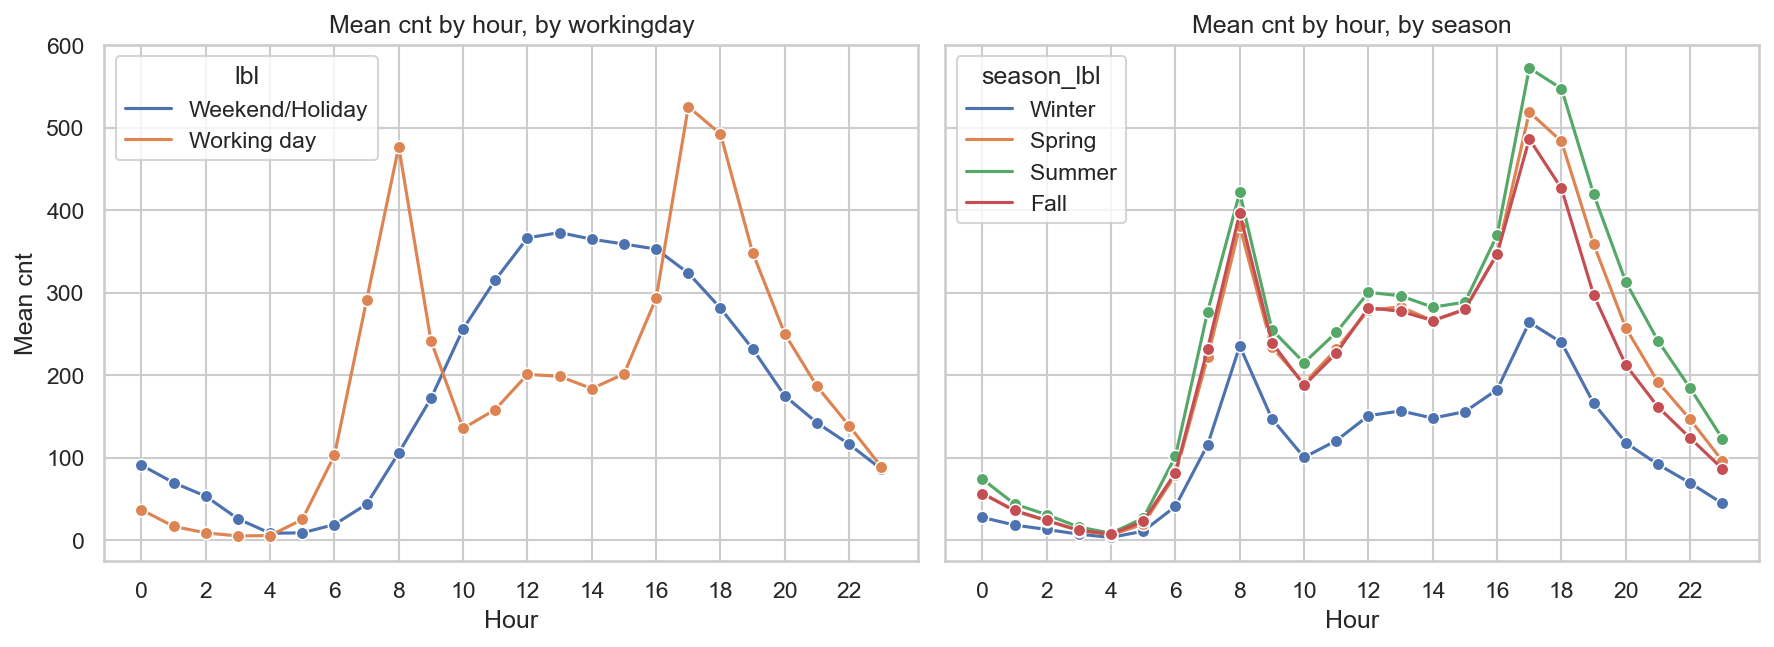

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

hourly_wd = df.groupby(['hr','workingday'])['cnt'].mean().reset_index()
hourly_wd['lbl'] = hourly_wd['workingday'].map({0:'Weekend/Holiday', 1:'Working day'})
sns.lineplot(data=hourly_wd, x='hr', y='cnt', hue='lbl', marker='o', ax=axes[0])
axes[0].set_title('Mean cnt by hour, by workingday')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Mean cnt')
axes[0].set_xticks(range(0,24,2))

hourly_s = df.groupby(['hr','season_lbl'])['cnt'].mean().reset_index()
sns.lineplot(data=hourly_s, x='hr', y='cnt', hue='season_lbl',
             hue_order=['Winter','Spring','Summer','Fall'],
             marker='o', ax=axes[1])
axes[1].set_title('Mean cnt by hour, by season')
axes[1].set_xlabel('Hour'); axes[1].set_xticks(range(0,24,2))
plt.tight_layout(); savefig('fig02_hourly_patterns'); plt.show()


The dataset's most distinctive feature: on working days,
demand has a sharp bimodal commuter signature (08:00 + 17:00--18:00);
on weekends/holidays, a single broad midday hump. Season scales the
curve but does not reshape it.

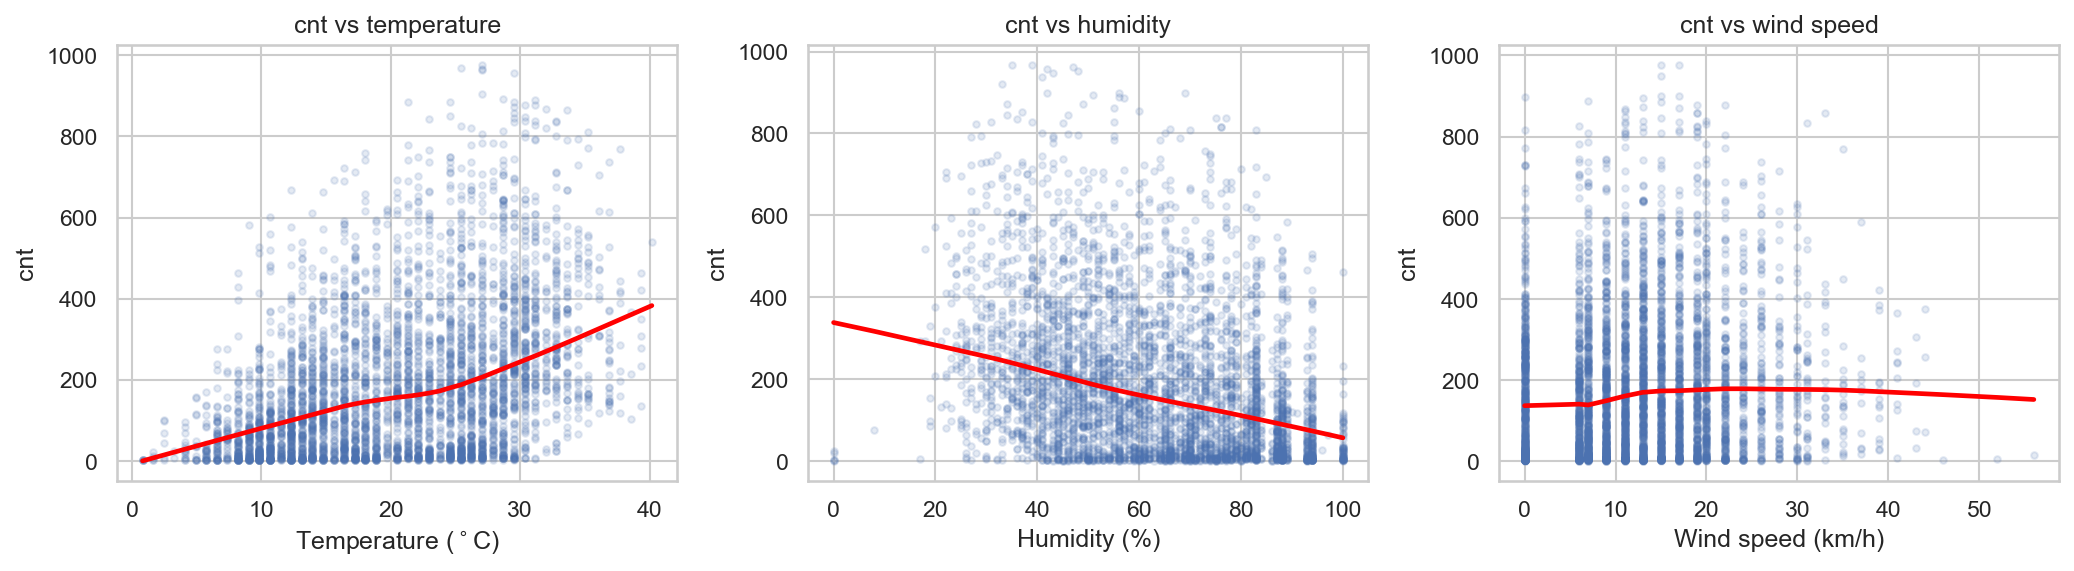

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.regplot(data=df.sample(4000, random_state=1), x='temp_c', y='cnt',
            scatter_kws={'alpha':0.15, 's':10}, line_kws={'color':'red'},
            lowess=True, ax=axes[0])
axes[0].set_xlabel('Temperature (°C)'); axes[0].set_ylabel('cnt')
axes[0].set_title('cnt vs temperature')

sns.regplot(data=df.sample(4000, random_state=2), x='hum_pct', y='cnt',
            scatter_kws={'alpha':0.15, 's':10}, line_kws={'color':'red'},
            lowess=True, ax=axes[1])
axes[1].set_xlabel('Humidity (%)'); axes[1].set_ylabel('cnt')
axes[1].set_title('cnt vs humidity')

sns.regplot(data=df.sample(4000, random_state=3), x='wind_kmh', y='cnt',
            scatter_kws={'alpha':0.15, 's':10}, line_kws={'color':'red'},
            lowess=True, ax=axes[2])
axes[2].set_xlabel('Wind speed (km/h)'); axes[2].set_ylabel('cnt')
axes[2].set_title('cnt vs wind speed')
plt.tight_layout(); savefig('fig03_weather_scatter'); plt.show()


Temperature: clearly positive (monotone up to ~30°C, mild concavity above).
Humidity: clearly negative, especially above 80%.
Wind speed: mild negative trend with wide spread.

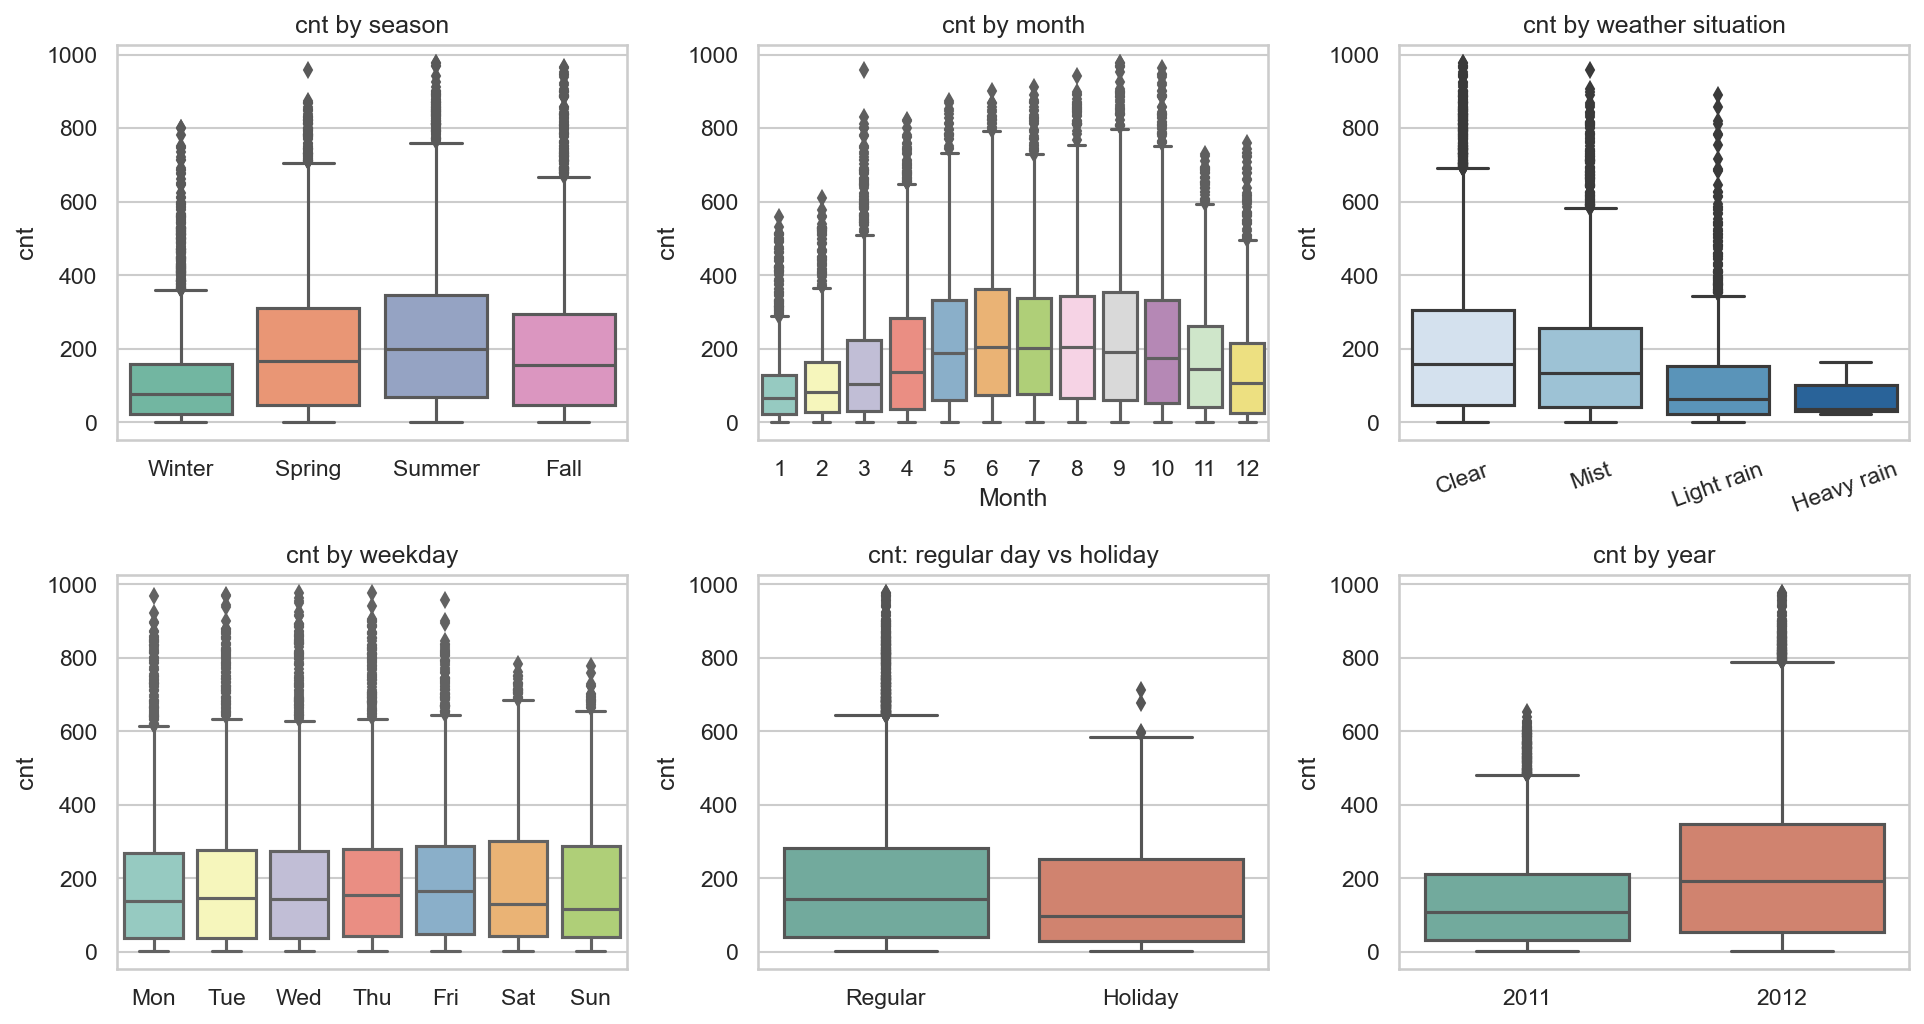

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

sns.boxplot(data=df, x='season_lbl', y='cnt',
            order=['Winter','Spring','Summer','Fall'],
            ax=axes[0,0], palette='Set2')
axes[0,0].set_title('cnt by season'); axes[0,0].set_xlabel('')

sns.boxplot(data=df, x='mnth', y='cnt', ax=axes[0,1], palette='Set3')
axes[0,1].set_title('cnt by month'); axes[0,1].set_xlabel('Month')

sns.boxplot(data=df, x='weather_lbl', y='cnt',
            order=['Clear','Mist','Light rain','Heavy rain'],
            ax=axes[0,2], palette='Blues')
axes[0,2].set_title('cnt by weathersit'); axes[0,2].set_xlabel('')
axes[0,2].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='weekday_lbl', y='cnt',
            order=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
            ax=axes[1,0], palette='Set3')
axes[1,0].set_title('cnt by weekday'); axes[1,0].set_xlabel('')

sns.boxplot(data=df, x='holiday', y='cnt', ax=axes[1,1],
            palette=['#69b3a2','#e07a5f'])
axes[1,1].set_xticklabels(['Regular','Holiday'])
axes[1,1].set_title('cnt: regular vs holiday'); axes[1,1].set_xlabel('')

sns.boxplot(data=df, x='year_lbl', y='cnt', ax=axes[1,2],
            palette=['#69b3a2','#e07a5f'])
axes[1,2].set_title('cnt by year'); axes[1,2].set_xlabel('')

plt.tight_layout(); savefig('fig17_categorical_panel'); plt.show()


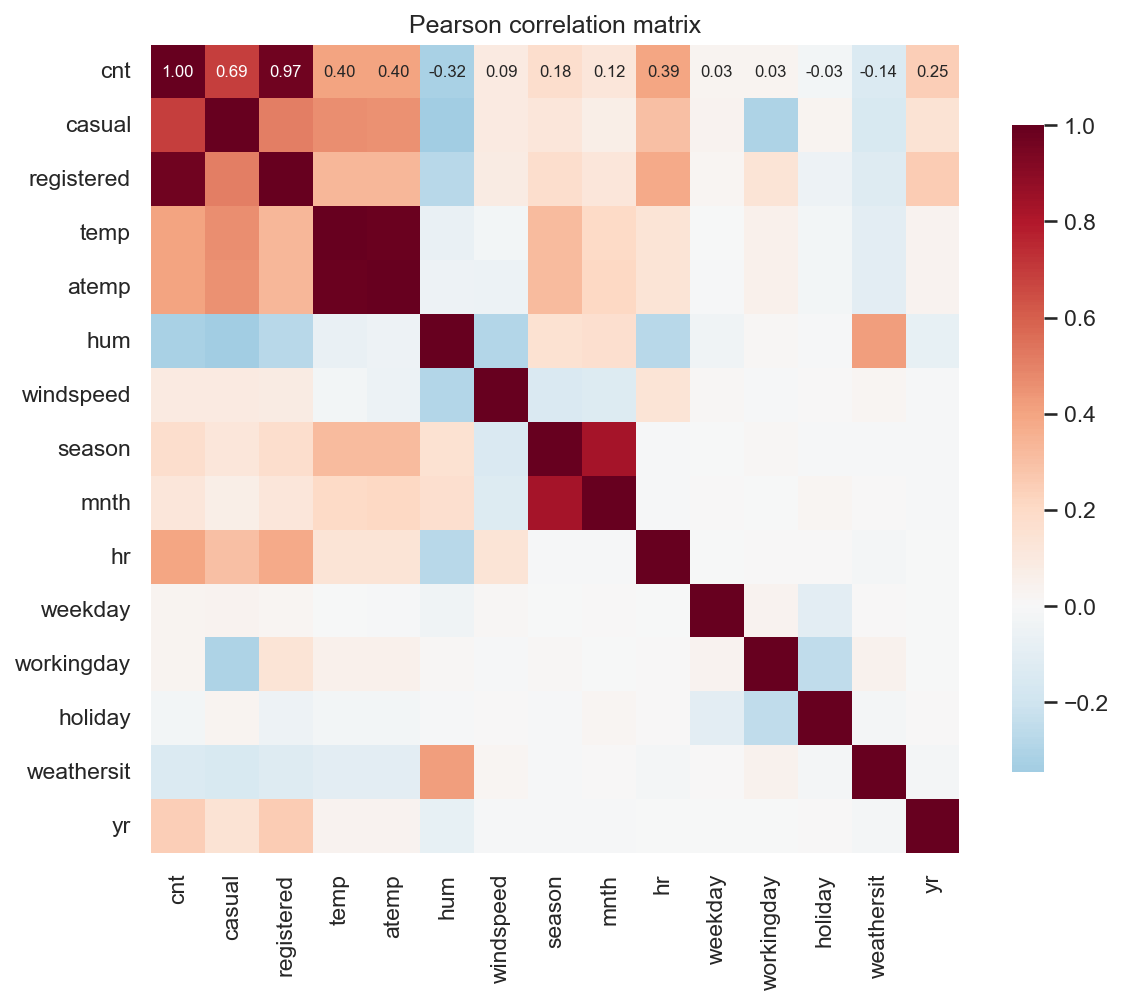

In [8]:
num_cols = ['cnt','casual','registered','temp','atemp','hum','windspeed',
            'season','mnth','hr','weekday','workingday','holiday','weathersit','yr']
corr = df[num_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink':.8}, annot_kws={'size':8})
plt.title('Pearson correlation matrix')
savefig('fig04_correlation_matrix'); plt.show()


## 2. K-means clustering

We treat each hour as an observation and cluster the 17,379 hours
using the feature set
$$(\texttt{cnt},\ \texttt{temp},\ \texttt{hum},\ \texttt{windspeed},\
   \texttt{hr},\ \texttt{workingday},\ \texttt{season},\
   \texttt{weathersit}),$$
all standardized to mean 0, variance 1. Including `cnt` as a feature
makes the regimes organize themselves around demand level together
with the conditions that produce it.


In [9]:
cluster_feats = ['cnt','temp','hum','windspeed',
                 'hr','workingday','season','weathersit']
X_c = df[cluster_feats].values
scaler_c = StandardScaler().fit(X_c)
X_cs = scaler_c.transform(X_c)
print('Clustering matrix shape:', X_cs.shape)


Clustering matrix shape: (17379, 8)


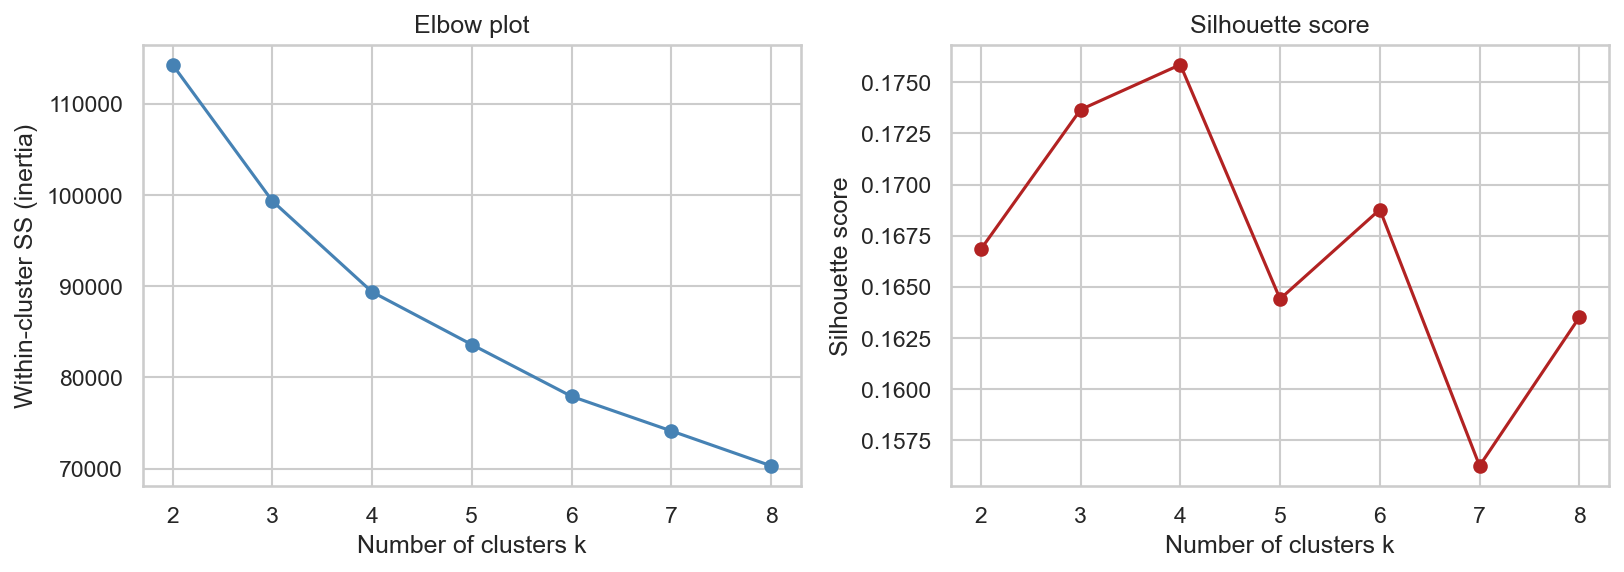

Silhouette by k: {2: 0.167, 3: 0.174, 4: 0.176, 5: 0.164, 6: 0.169, 7: 0.156, 8: 0.163}


In [10]:
ks = list(range(2, 9))
wss, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=5, random_state=0).fit(X_cs)
    wss.append(km.inertia_)
    sils.append(silhouette_score(X_cs, km.labels_, sample_size=4000,
                                 random_state=0))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ks, wss, '-o', color='steelblue')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Within-cluster SS')
axes[0].set_title('Elbow plot')
axes[1].plot(ks, sils, '-o', color='firebrick')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
axes[1].set_title('Silhouette score')
plt.tight_layout(); savefig('fig05_kmeans_diagnostics'); plt.show()

print('Silhouette by k:', dict(zip(ks, [round(s,3) for s in sils])))


Elbow + silhouette suggest **$k = 4$** as a reasonable balance:
a clear bend in the inertia curve and a local silhouette peak
at $k=4$ (around 0.18).

Cluster sizes: {'0': 3738, '1': 6247, '2': 4096, '3': 3298}

Centroids on raw scale:
              cnt       temp        hum  windspeed         hr workingday     season weathersit
C0:        111.15       0.30       0.50       0.24      11.94       0.66       1.17       1.23
C1:        346.82       0.63       0.53       0.20      15.80       0.71       2.96       1.15
C2:         57.07       0.50       0.75       0.12       4.13       0.61       3.02       1.22
C3:        144.07       0.46       0.82       0.20      12.24       0.75       2.50       2.42


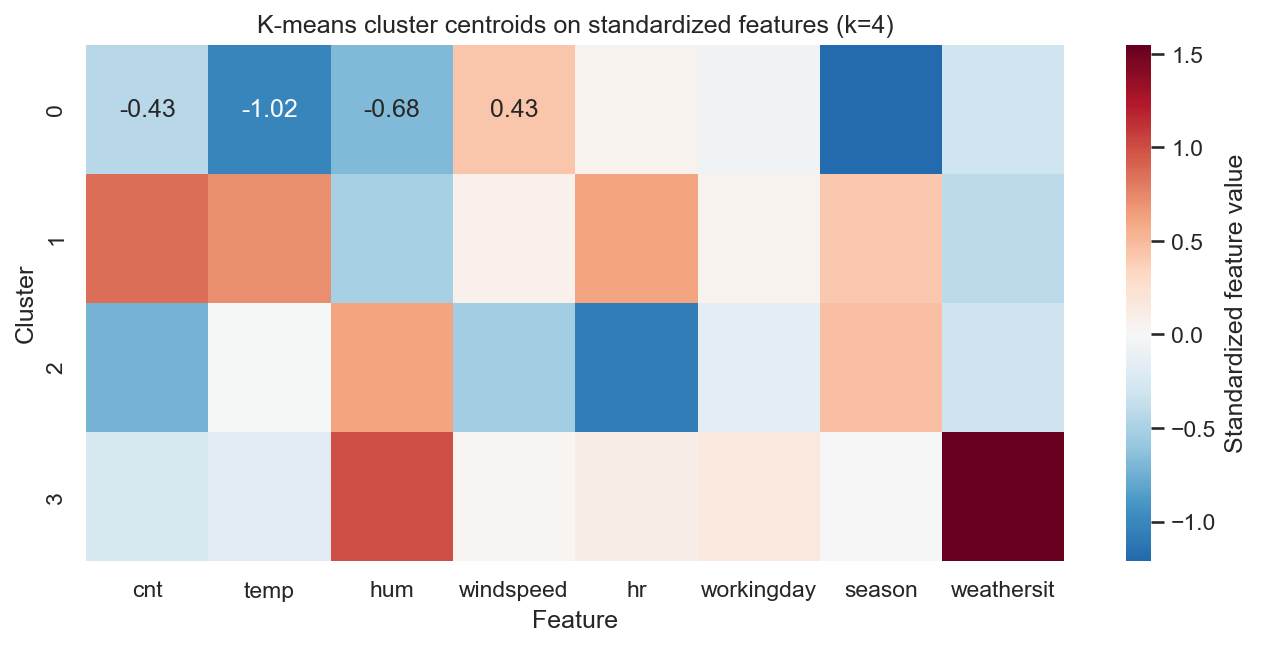

In [11]:
k = 4
km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_cs)
df['cluster'] = km.labels_

centroids_std = pd.DataFrame(km.cluster_centers_, columns=cluster_feats)
centroids_raw = pd.DataFrame(scaler_c.inverse_transform(km.cluster_centers_),
                             columns=cluster_feats)
print('Cluster sizes:', df['cluster'].value_counts().sort_index().to_dict())
print()
print('Centroids (raw scale):')
print(centroids_raw.round(2))

plt.figure(figsize=(9, 4.5))
sns.heatmap(centroids_std.round(2), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0,
            cbar_kws={'label':'Standardized value'})
plt.xlabel('Feature'); plt.ylabel('Cluster')
plt.title(f'K-means cluster centroids (k={k})')
plt.tight_layout(); savefig('fig06_cluster_centroids'); plt.show()


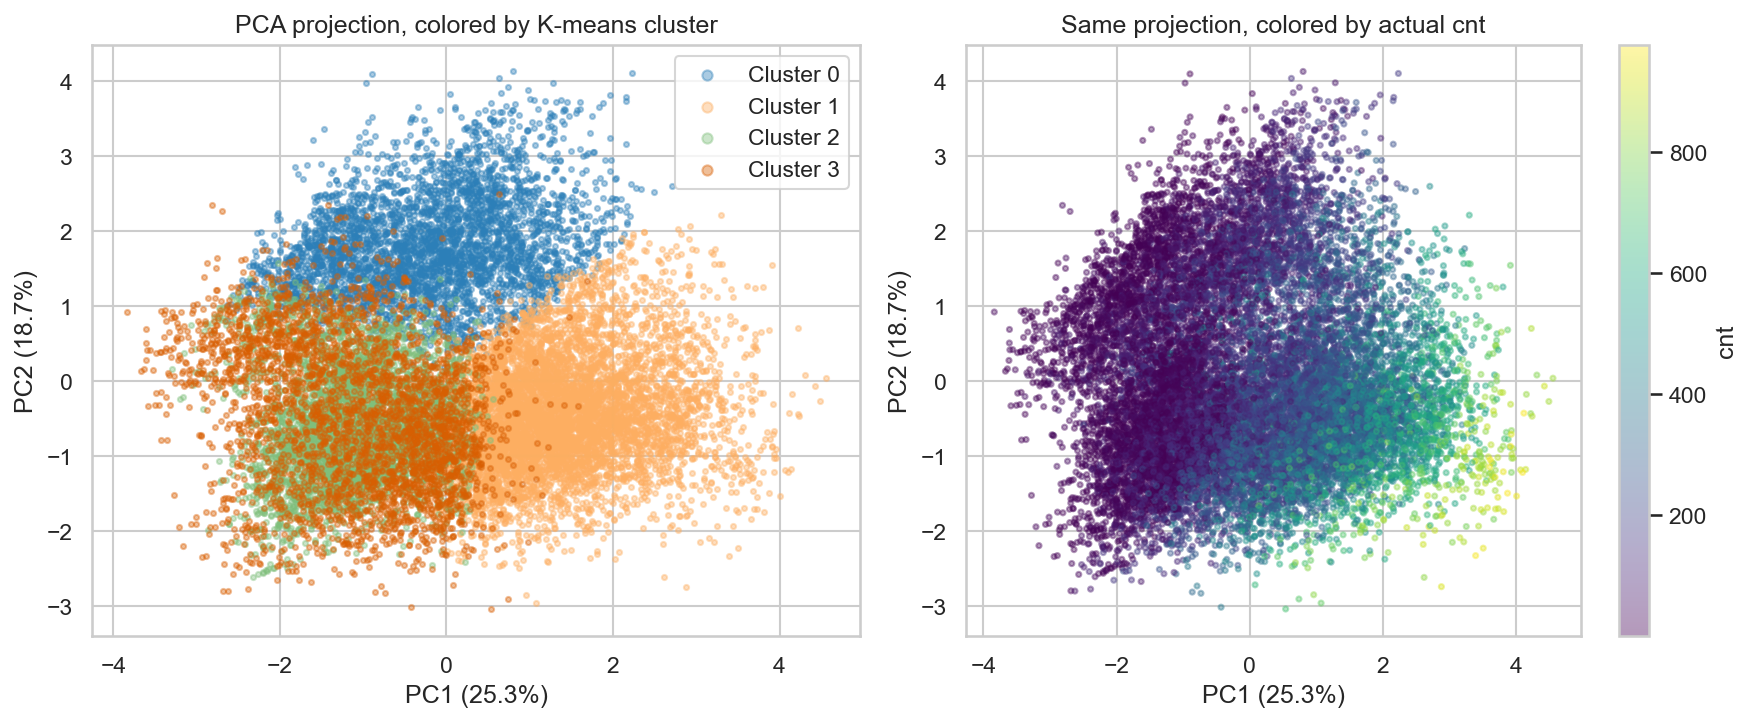

PC1, PC2 variance explained:  [0.253, 0.187]


In [12]:
pca = PCA(n_components=2).fit(X_cs)
scores = pca.transform(X_cs)
palette = ['#2c7fb8','#fdae61','#7fbf7b','#d95f02']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for c in range(k):
    sel = km.labels_ == c
    axes[0].scatter(scores[sel,0], scores[sel,1], s=6, alpha=0.4,
                    color=palette[c], label=f'Cluster {c}')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA projection, colored by cluster')
axes[0].legend(loc='best', markerscale=2)

sc = axes[1].scatter(scores[:,0], scores[:,1], s=6, alpha=0.4,
                     c=df['cnt'], cmap='viridis')
plt.colorbar(sc, ax=axes[1], label='cnt')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Same projection, colored by actual cnt')
plt.tight_layout(); savefig('fig07_cluster_pca_scatter'); plt.show()

print('PC1, PC2 variance explained: ',
      [round(x,3) for x in pca.explained_variance_ratio_])


The four clusters form contiguous regions in PC1--PC2. Coloring
the same projection by actual `cnt` (right panel) shows that PC1 is
essentially aligned with demand level --- the clusters are ordered by
`cnt` along PC1 in addition to being separated by hour/weather along
PC2.

             n  mean_cnt  temp_c  hum_pct  workingday_pct  weathersit
cluster                                                             
0         3738    110.99   12.31    49.69            0.66        1.23
1         6247    346.94   25.95    52.60            0.71        1.15
2         4096     57.11   20.31    74.64            0.61        1.22
3         3298    144.49   19.03    81.87            0.75        2.42


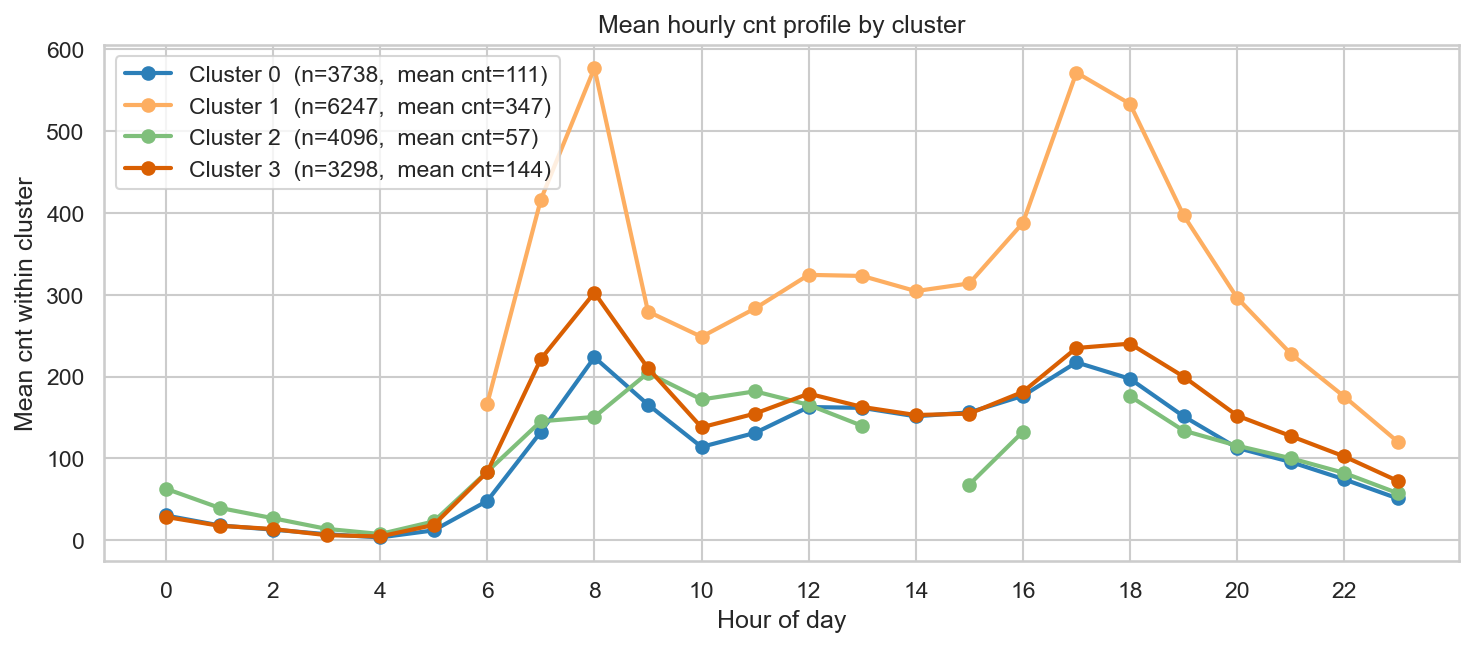

In [13]:
prof = df.groupby(['cluster','hr'])['cnt'].mean().unstack('hr')
cluster_summary = (df.groupby('cluster')
        .agg(n=('cnt','size'), mean_cnt=('cnt','mean'),
             temp_c=('temp_c','mean'), hum_pct=('hum_pct','mean'),
             workingday_pct=('workingday','mean'),
             weathersit=('weathersit','mean')))
print(cluster_summary.round(2))

fig, ax = plt.subplots(figsize=(10, 4.5))
for c in range(k):
    n = int((km.labels_==c).sum())
    ax.plot(range(24), prof.loc[c], '-o', color=palette[c], lw=2,
            label=f'Cluster {c}  (n={n}, mean cnt='
                  f'{cluster_summary.loc[c,"mean_cnt"]:.0f})')
ax.set_xticks(range(0,24,2))
ax.set_xlabel('Hour of day'); ax.set_ylabel('Mean cnt')
ax.set_title('Mean hourly cnt by cluster')
ax.legend(loc='upper left')
plt.tight_layout(); savefig('fig08_cluster_hour_profile'); plt.show()


The per-cluster hourly profile makes the labels crisp:
cluster~1 is the **high-demand cluster** (warm afternoons/commuter hours),
cluster~2 is the **night cluster**, cluster~0 is the **off-peak cool**,
and cluster~3 is the **bad-weather** group.

## 3. Factor analysis



                 F1     F2     F3   comm
         cnt   -0.09  +0.85  +0.09  0.74
        temp   -0.10  +0.50  -0.23  0.31
         hum   +0.41  -0.28  -0.58  0.59
   windspeed   +0.05  +0.08  +0.45  0.21
          hr   +0.02  +0.42  +0.27  0.26
  workingday   +0.05  +0.05  -0.03  0.01
      season   -0.03  +0.27  -0.43  0.26
  weathersit   +0.90  -0.06  -0.05  0.82
          yr   -0.00  +0.24  +0.04  0.06


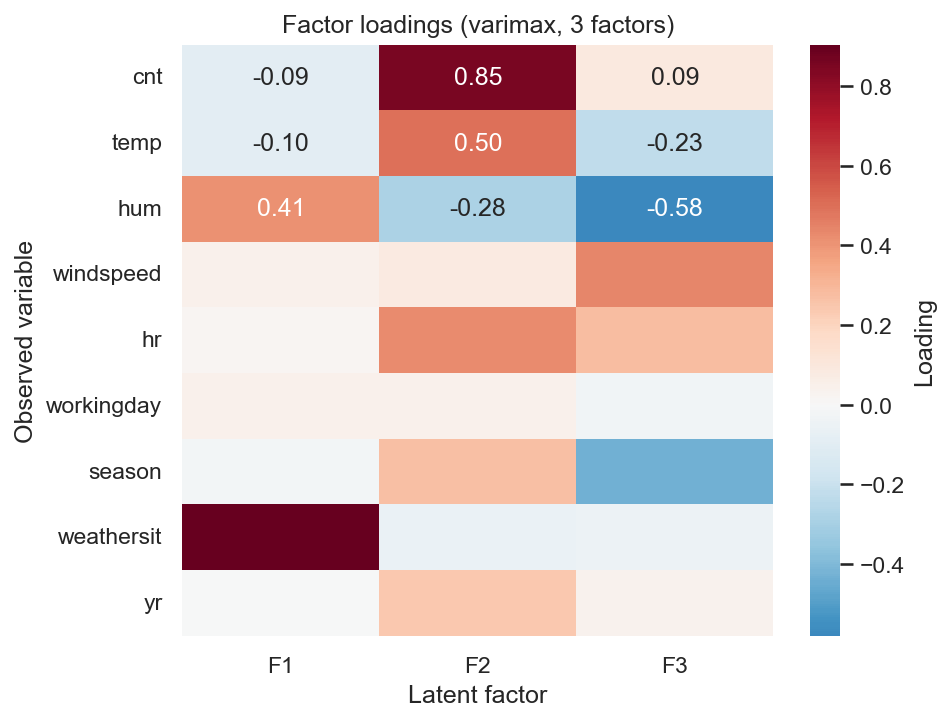

In [14]:
fa_feats = ['cnt','temp','hum','windspeed',
            'hr','workingday','season','weathersit','yr']
X_f = df[fa_feats].values
X_fs = StandardScaler().fit_transform(X_f)

fa = FactorAnalysis(n_components=3, rotation='varimax', random_state=0).fit(X_fs)
loadings = pd.DataFrame(fa.components_.T, index=fa_feats,
                        columns=[f'F{i+1}' for i in range(3)])
loadings['communality'] = (loadings**2).sum(axis=1)
print('Factor loadings (varimax-rotated):')
print(loadings.round(2))

plt.figure(figsize=(6.5, 5))
sns.heatmap(loadings[['F1','F2','F3']], annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, cbar_kws={'label':'Loading'})
plt.title('Factor loadings (varimax)')
plt.xlabel('Factor'); plt.ylabel('Variable')
plt.tight_layout(); savefig('fig09_fa_loadings'); plt.show()


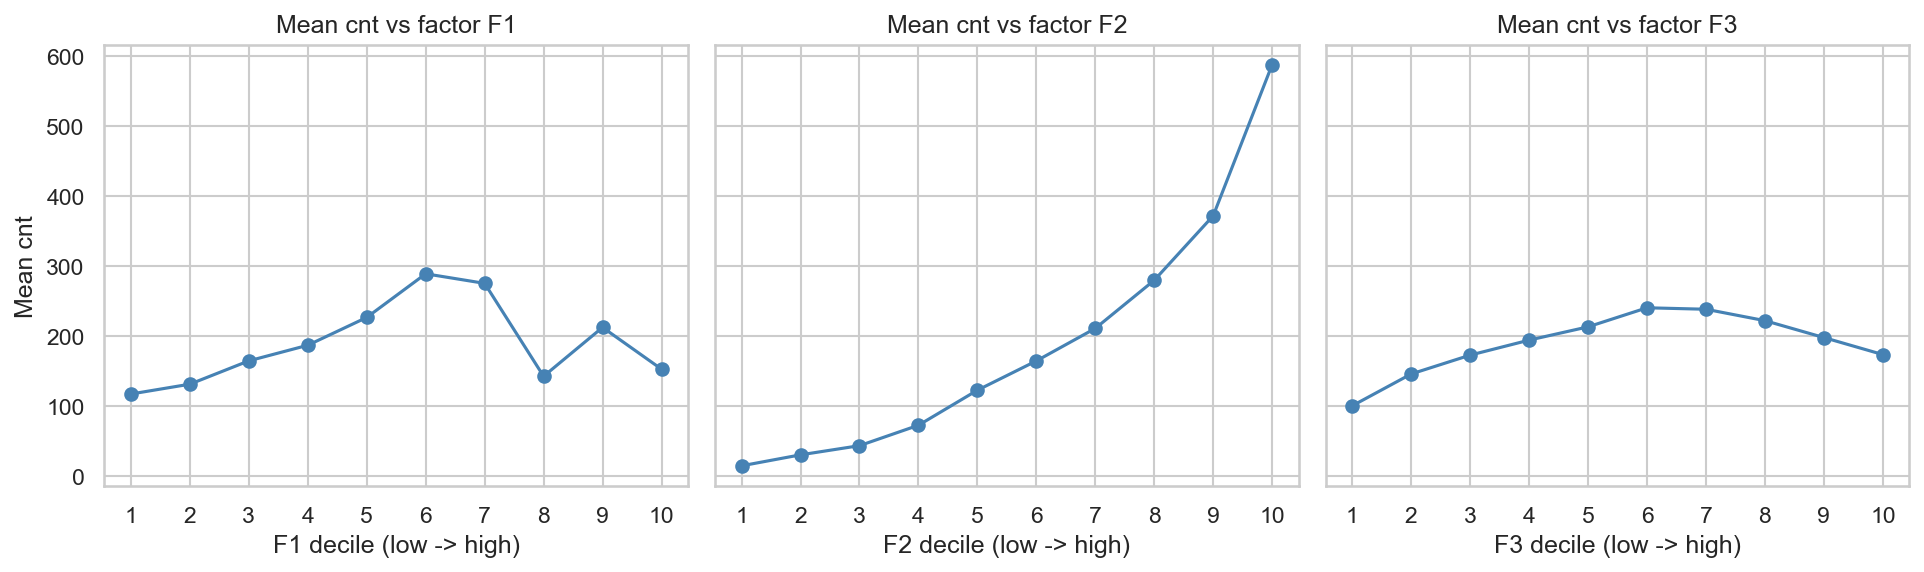

In [15]:
scores_fa = fa.transform(X_fs)
df_fa = df.copy()
for i in range(3):
    df_fa[f'F{i+1}'] = scores_fa[:, i]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for i in range(3):
    col = f'F{i+1}'
    bins = pd.qcut(df_fa[col], 10, duplicates='drop')
    by = df_fa.groupby(bins)['cnt'].mean()
    axes[i].plot(range(len(by)), by.values, '-o', color='steelblue')
    axes[i].set_xticks(range(len(by)))
    axes[i].set_xticklabels(range(1, len(by)+1))
    axes[i].set_xlabel(f'{col} decile')
    axes[i].set_title(f'Mean cnt vs {col}')
axes[0].set_ylabel('Mean cnt')
plt.tight_layout(); savefig('fig10_fa_cnt_vs_factor'); plt.show()


## 4. Lasso regression of `cnt`



In [16]:
work = df.copy()
work['weather3'] = np.where(work['weathersit']==4, 3, work['weathersit'])
cat_cols = ['hr','weekday','season','weather3']
num_cols_l = ['temp','hum','windspeed','yr','workingday','holiday']
X_cat = pd.get_dummies(work[cat_cols].astype(str), drop_first=True)
X_num = work[num_cols_l].astype(float)
X_full = pd.concat([X_num, X_cat], axis=1)
feature_names = X_full.columns.tolist()
y = np.log1p(work['cnt'].values)
scaler = StandardScaler()
X_std = scaler.fit_transform(X_full.values)
print('Design matrix:', X_std.shape)


Design matrix: (17379, 40)


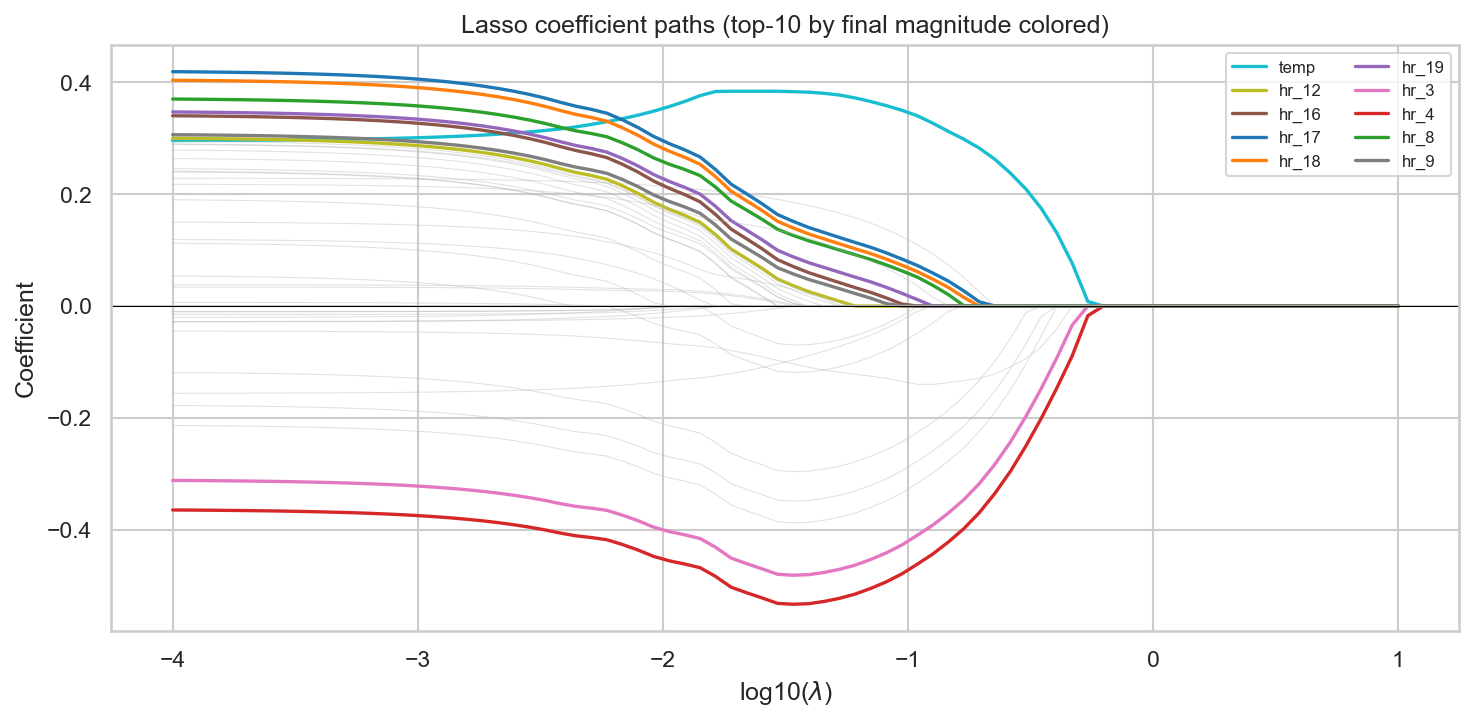

In [17]:
alphas = np.logspace(-4, 1, 80)
alphas_path, coefs_path, _ = lasso_path(X_std, y, alphas=alphas, max_iter=5000)
log_alpha = np.log10(alphas_path)

mag_at_min = np.abs(coefs_path[:, -1])
top_idx = np.argsort(mag_at_min)[::-1][:10]

fig, ax = plt.subplots(figsize=(10, 5))
for j in range(coefs_path.shape[0]):
    if j in top_idx:
        color = plt.cm.tab10(np.where(top_idx == j)[0][0] % 10)
        lw, label = 1.6, feature_names[j]
    else:
        color, lw, label = (0.7,0.7,0.7,0.4), 0.5, None
    ax.plot(log_alpha, coefs_path[j], color=color, lw=lw, label=label)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('log10(lambda)'); ax.set_ylabel('Coefficient')
ax.set_title('Lasso coefficient paths (top-10 by final magnitude colored)')
ax.legend(loc='best', fontsize=8, ncol=2)
plt.tight_layout(); savefig('fig11_lasso_path'); plt.show()


Each line is the trajectory of one coefficient as $\lambda$
varies. At large $\lambda$ (left), every coefficient is zero; as
$\lambda$ shrinks, variables enter one at a time. The colored top-10
end up as the largest-magnitude coefficients.

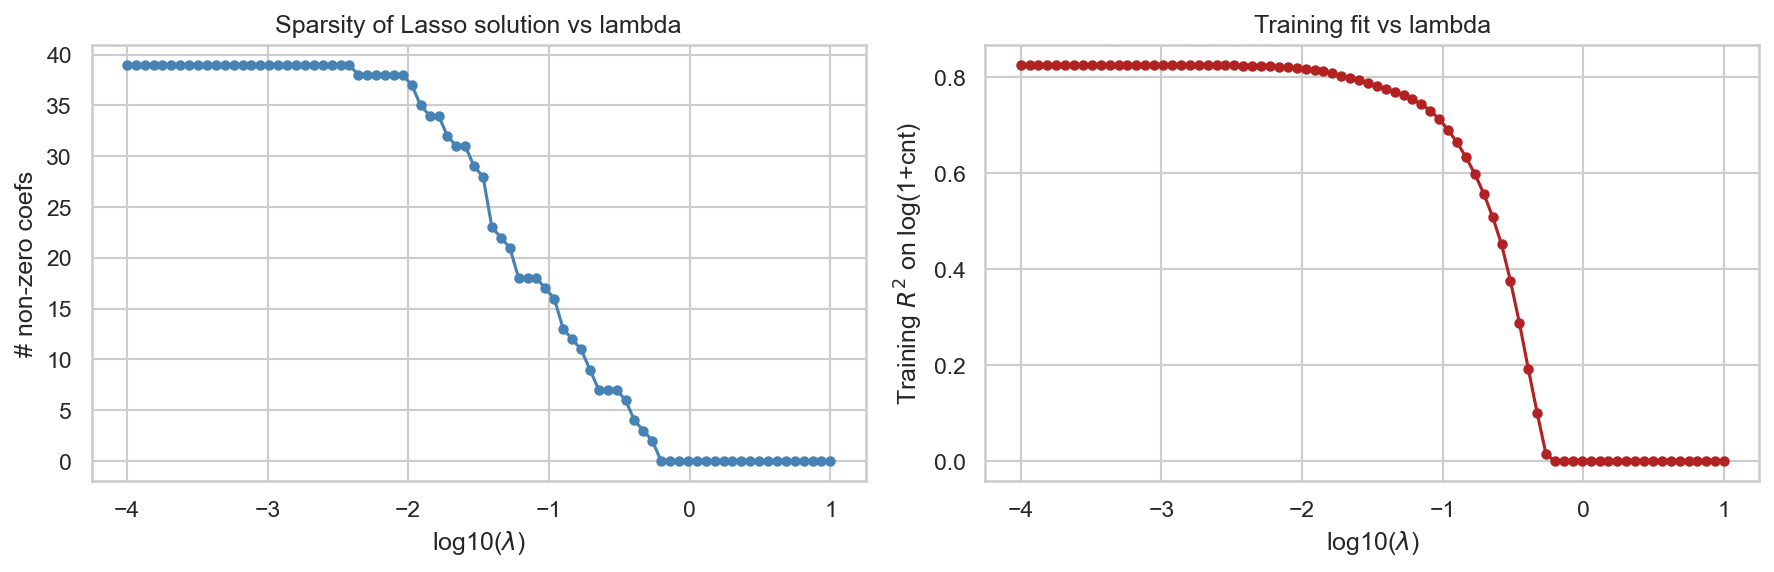

In [18]:
n_nonzero = (np.abs(coefs_path) > 1e-8).sum(axis=0)
y_pred = X_std @ coefs_path
sse = ((y[:,None] - (y_pred + y.mean()))**2).sum(axis=0)
sst = ((y - y.mean())**2).sum()
r2 = 1 - sse / sst

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(log_alpha, n_nonzero, '-o', color='steelblue', ms=4)
axes[0].set_xlabel('log10(lambda)')
axes[0].set_ylabel('# non-zero coefficients')
axes[0].set_title('Sparsity vs lambda')

axes[1].plot(log_alpha, r2, '-o', color='firebrick', ms=4)
axes[1].set_xlabel('log10(lambda)')
axes[1].set_ylabel('Training R²')
axes[1].set_title('Training fit vs lambda')

plt.tight_layout(); savefig('fig12_lasso_sparsity_and_r2'); plt.show()


As $\lambda$ shrinks, more variables enter and $R^2$ rises
toward the unregularized OLS value. The curves are smooth and
saturate around log10 $\lambda \approx -2$.

In [19]:
kf = KFold(n_splits=5, shuffle=True, random_state=0)
alphas_cv = np.logspace(-4, 1, 100)
lcv = LassoCV(alphas=alphas_cv, cv=kf, max_iter=5000, n_jobs=1).fit(X_std, y)
ols = LinearRegression().fit(X_std, y)

# 1-SE rule (most regularized lambda within 1 SE of min CV-MSE).
mse_path  = lcv.mse_path_
mse_mean  = mse_path.mean(axis=1)
mse_sem   = mse_path.std (axis=1) / np.sqrt(mse_path.shape[1])
i_min     = int(np.argmin(mse_mean))
thresh    = mse_mean[i_min] + mse_sem[i_min]
eligible  = np.where(mse_mean <= thresh)[0]
alpha_grid= lcv.alphas_
i_1se     = eligible[np.argmax(alpha_grid[eligible])]
alpha_1se = float(alpha_grid[i_1se])
lasso_1se = Lasso(alpha=alpha_1se, max_iter=5000).fit(X_std, y)

print(f'lambda_min : {lcv.alpha_:.5g}  log10={np.log10(lcv.alpha_):+.3f}')
print(f'lambda_1se : {alpha_1se:.5g}  log10={np.log10(alpha_1se):+.3f}')
print(f'non-zero @ lambda_min : {(np.abs(lcv.coef_)>1e-8).sum()}')
print(f'non-zero @ lambda_1se : {(np.abs(lasso_1se.coef_)>1e-8).sum()}')
print(f'R² @ lambda_min : {lcv.score(X_std, y):.4f}')
print(f'R² @ lambda_1se : {lasso_1se.score(X_std, y):.4f}')
print(f'R² OLS          : {ols.score(X_std, y):.4f}')


lambda_min : 0.0001  log10=-4.000
lambda_1se : 0.004132  log10=-2.384
non-zero @ lambda_min : 39
non-zero @ lambda_1se : 39
R² @ lambda_min : 0.8262
R² @ lambda_1se : 0.8243
R² OLS          : 0.8262


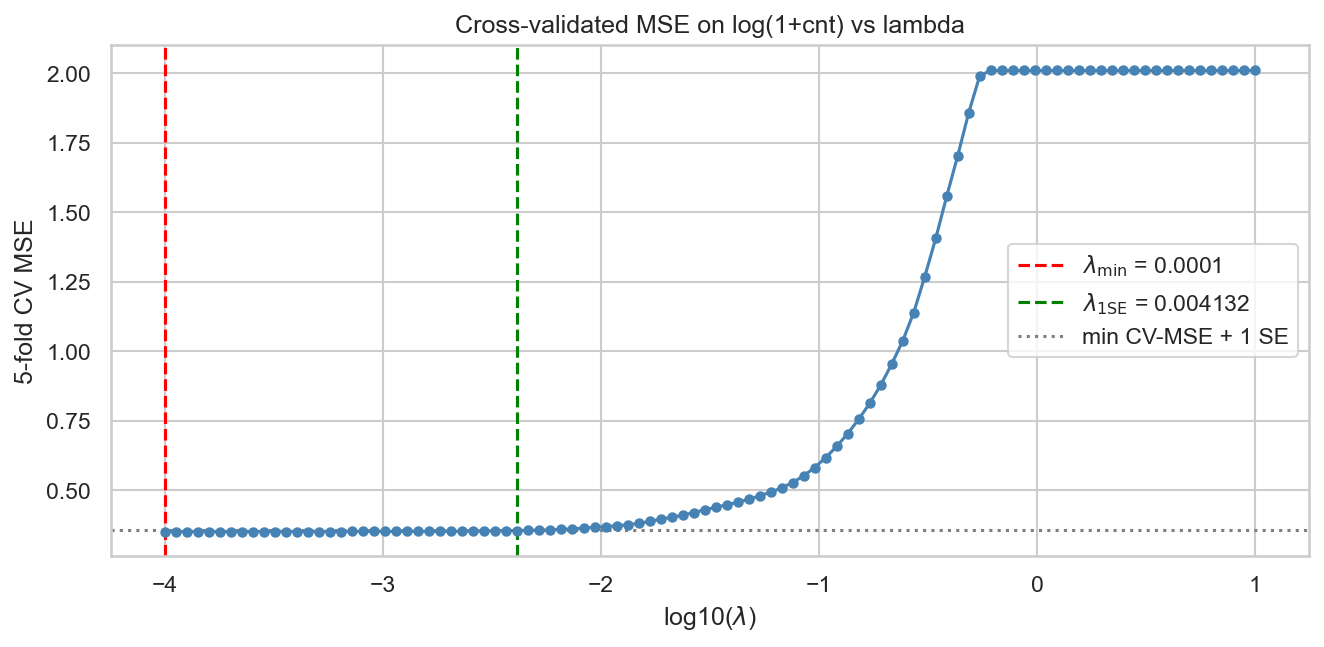

In [20]:
order = np.argsort(alpha_grid)
plt.figure(figsize=(9, 4.5))
plt.errorbar(np.log10(alpha_grid[order]), mse_mean[order],
             yerr=mse_sem[order],
             fmt='-o', ms=4, color='steelblue', ecolor='lightgrey',
             elinewidth=1, capsize=2)
plt.axvline(np.log10(lcv.alpha_), color='red', linestyle='--',
            label=f'lambda_min = {lcv.alpha_:.4g}')
plt.axvline(np.log10(alpha_1se), color='green', linestyle='--',
            label=f'lambda_1SE = {alpha_1se:.4g}')
plt.axhline(thresh, color='gray', linestyle=':', label='min + 1 SE')
plt.xlabel('log10(lambda)'); plt.ylabel('5-fold CV MSE')
plt.title('Cross-validated MSE on log(1+cnt) vs lambda')
plt.legend()
plt.tight_layout(); savefig('fig13_lassocv_mse'); plt.show()


The CV-MSE curve is very flat: lambda_min sits at the smallest
$\lambda$ we tried, and the 1-SE band only moves it slightly. The
horizontal "min + 1 SE" line crosses the curve far to the left of
where Lasso starts pruning variables.

Selected @ lambda_1SE (39 non-zero, top 20):
       feature  coef_lambda_1se
          hr_4  -0.410
         hr_17  +0.360
          hr_3  -0.357
         hr_18  +0.345
          temp  +0.319
          hr_8  +0.316
         hr_19  +0.290
         hr_16  +0.281
          hr_2  -0.260
          hr_9  +0.251
         hr_12  +0.241
         hr_13  +0.236
         hr_20  +0.233
         hr_15  +0.229
          hr_5  -0.223
            yr  +0.223
         hr_14  +0.219
         hr_11  +0.206
      season_4  +0.201
          hr_7  +0.192


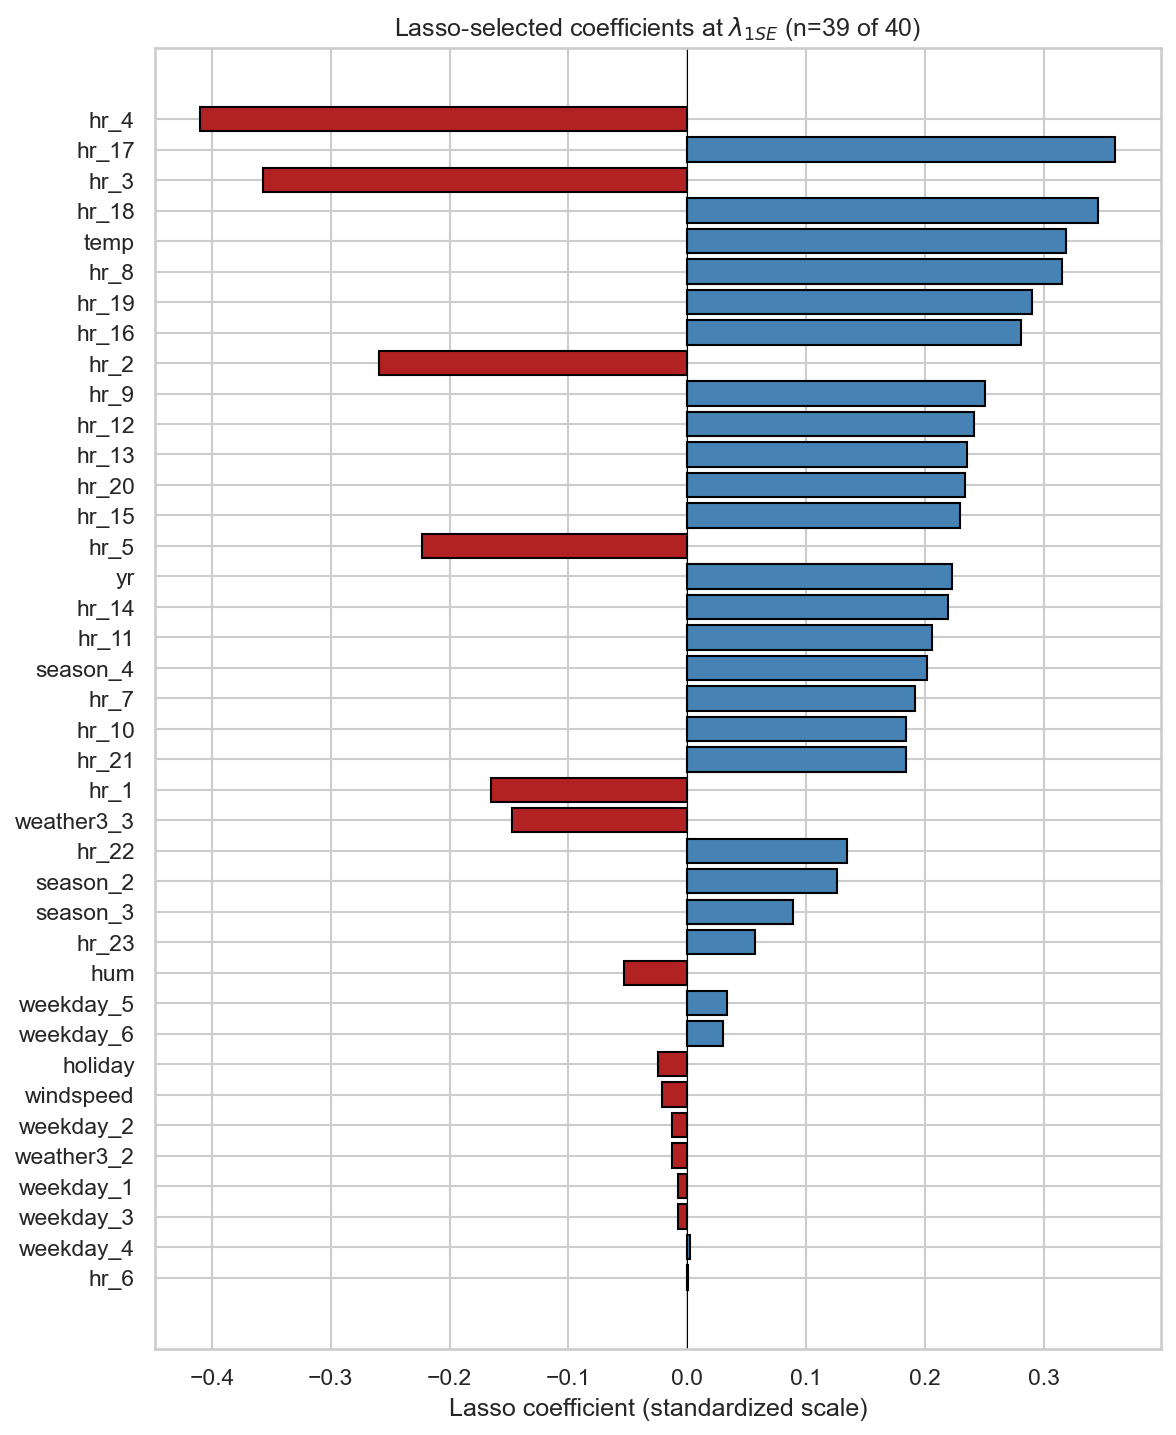

In [21]:
coef_table = pd.DataFrame({
    'feature'         : feature_names,
    'coef_lambda_min' : lcv.coef_,
    'coef_lambda_1se' : lasso_1se.coef_,
})
selected_1se = coef_table[np.abs(coef_table['coef_lambda_1se'])>1e-8].copy()
selected_1se['abs'] = selected_1se['coef_lambda_1se'].abs()
selected_1se = selected_1se.sort_values('abs', ascending=False)
print(f'Selected @ lambda_1SE ({len(selected_1se)} non-zero, top 20):')
print(selected_1se.head(20)[['feature','coef_lambda_1se','coef_lambda_min']]
      .round(3).to_string(index=False))

order_idx = selected_1se['coef_lambda_1se'].abs().sort_values().index
sel = selected_1se.loc[order_idx]
colors = ['firebrick' if c<0 else 'steelblue' for c in sel['coef_lambda_1se']]
plt.figure(figsize=(8, max(4, 0.25 * len(sel))))
plt.barh(range(len(sel)), sel['coef_lambda_1se'],
         color=colors, edgecolor='black')
plt.yticks(range(len(sel)), sel['feature'])
plt.axvline(0, color='black', lw=0.5)
plt.xlabel('Lasso coefficient (standardized)')
plt.title(f'Lasso-selected coefficients at lambda_1SE '
          f'(n={len(sel)} of {len(feature_names)})')
plt.tight_layout(); savefig('fig14_lasso_selected_coefs'); plt.show()


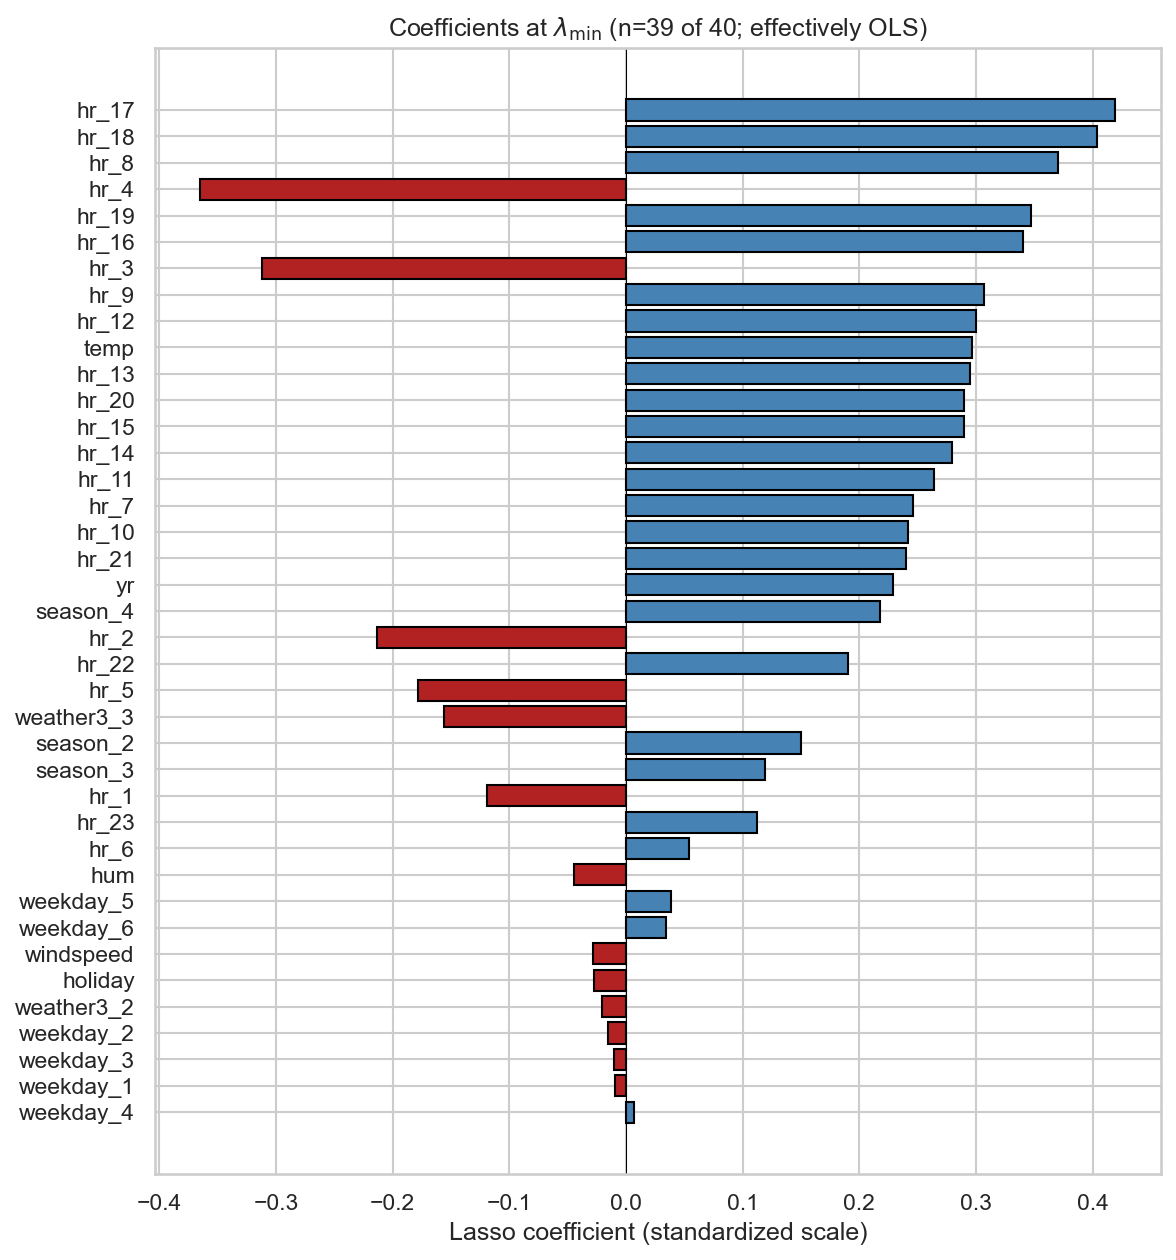

In [22]:
# All coefficients at lambda_min (essentially OLS)
selected_min = coef_table.copy()
selected_min = selected_min[np.abs(selected_min['coef_lambda_min'])>1e-8]
selected_min['abs'] = selected_min['coef_lambda_min'].abs()
selected_min = selected_min.sort_values('abs', ascending=False)

order_idx_m = selected_min['coef_lambda_min'].abs().sort_values().index
sel_m = selected_min.loc[order_idx_m]
colors_m = ['firebrick' if c<0 else 'steelblue' for c in sel_m['coef_lambda_min']]
plt.figure(figsize=(8, max(5, 0.22 * len(sel_m))))
plt.barh(range(len(sel_m)), sel_m['coef_lambda_min'],
         color=colors_m, edgecolor='black')
plt.yticks(range(len(sel_m)), sel_m['feature'])
plt.axvline(0, color='black', lw=0.5)
plt.xlabel('Lasso coefficient (standardized)')
plt.title('Coefficients at lambda_min (effectively OLS, all 39 vars)')
plt.tight_layout(); savefig('fig15_lasso_coefs_lambda_min'); plt.show()


target 5 : lambda=0.4051, actual n_nonzero=4 , R²=0.1926
target 12: lambda=0.1461, actual n_nonzero=12, R²=0.6338
target 25: lambda=0.0393, actual n_nonzero=23, R²=0.7763
target 39: lambda=0.0038, actual n_nonzero=39, R²=0.8246


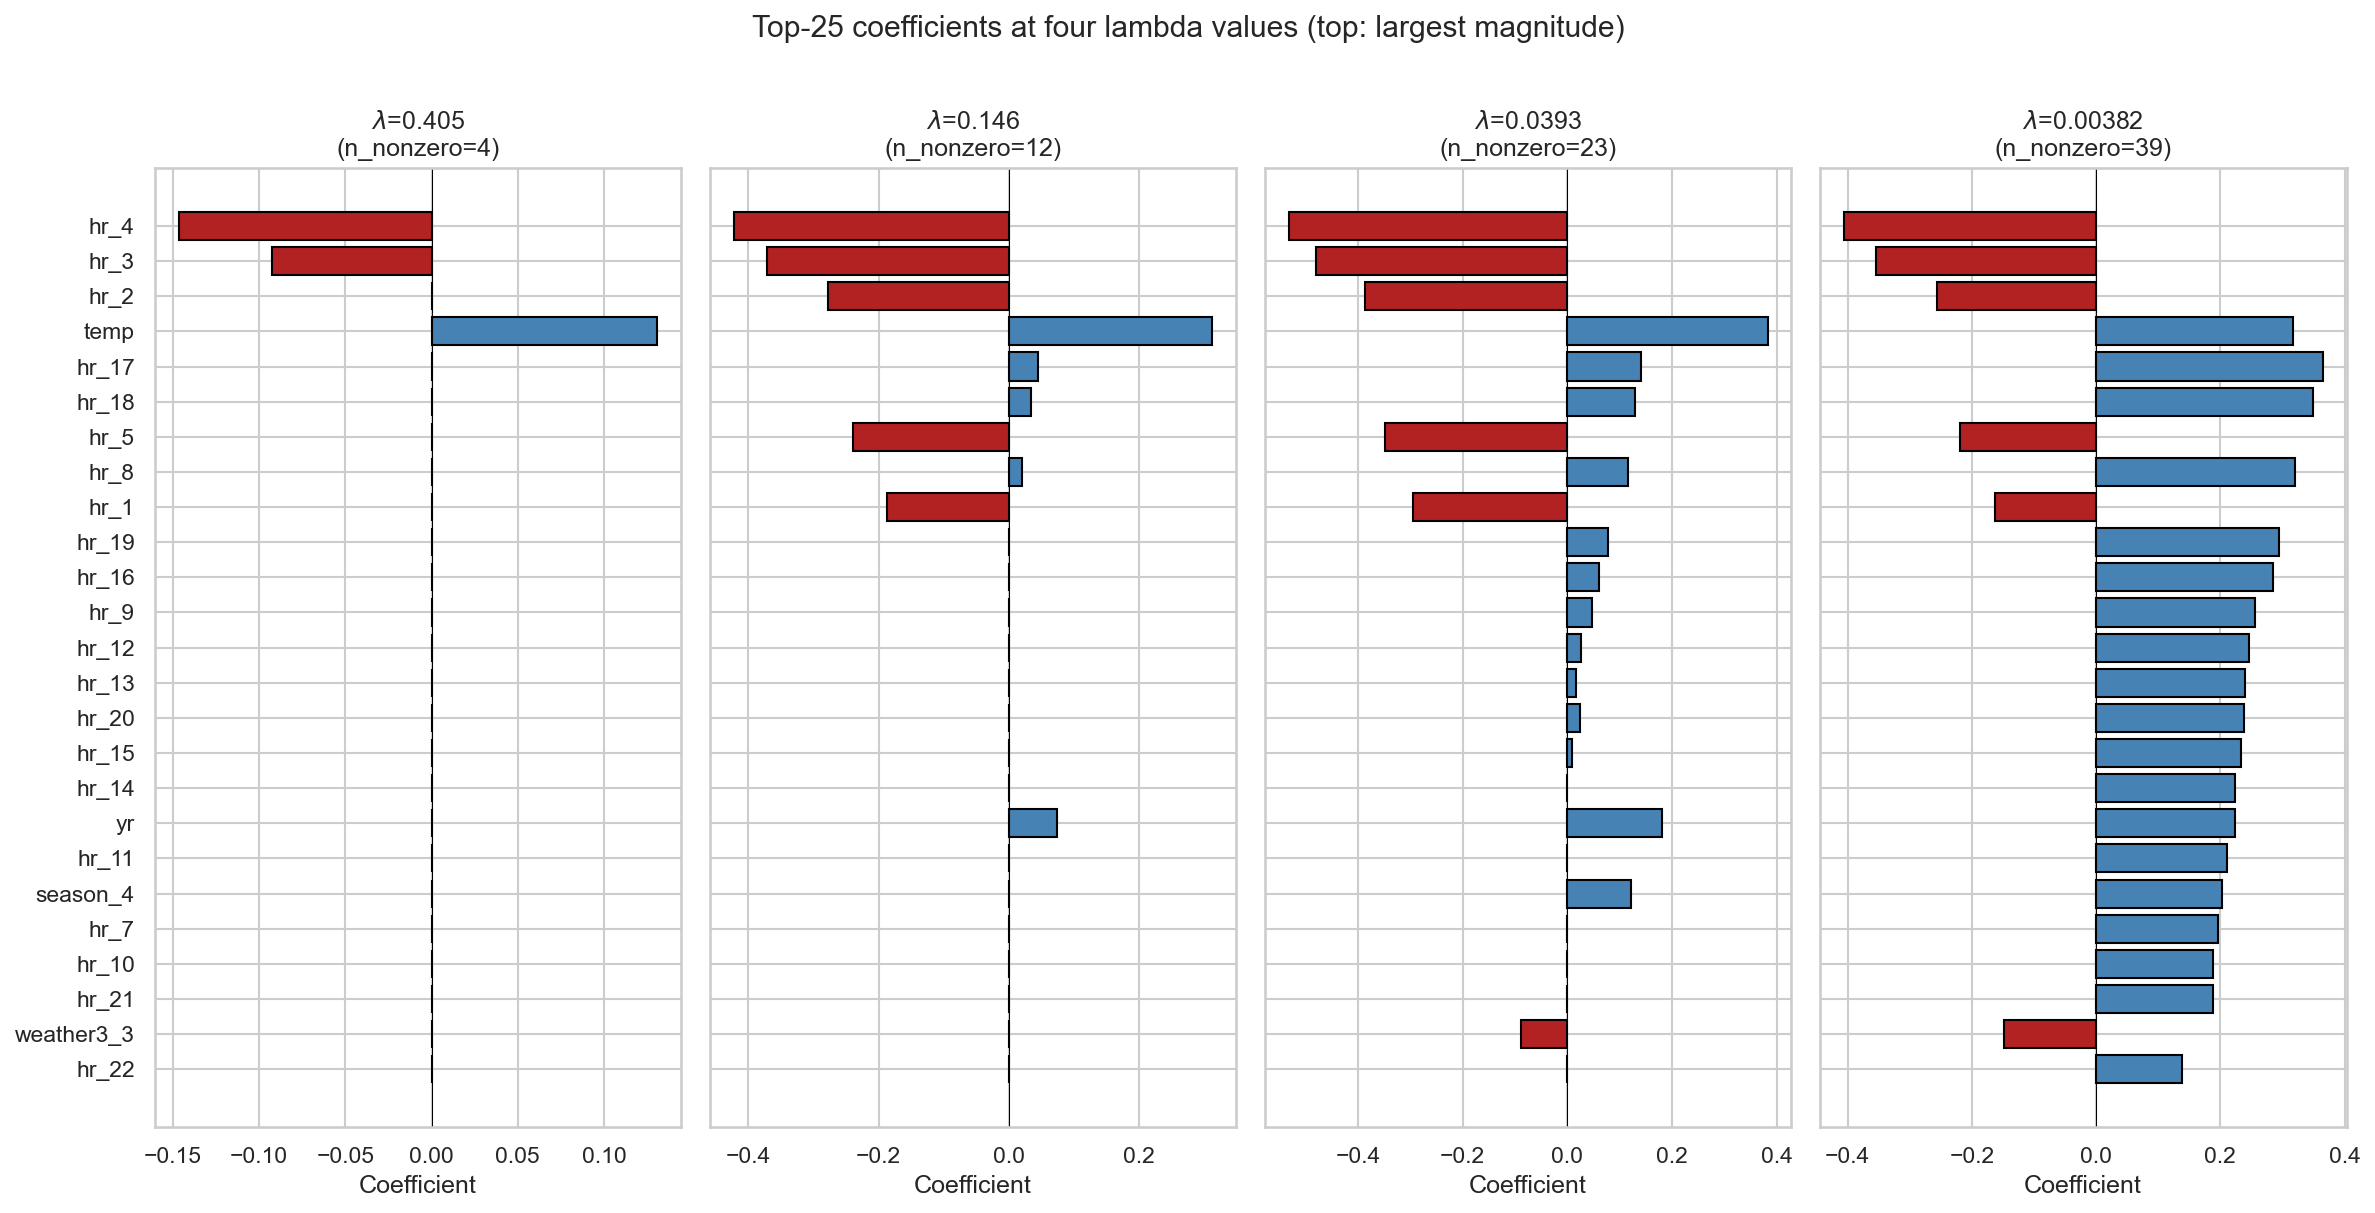

In [23]:
# Pick four lambdas along the path to show variable-selection trajectory
target_counts = [5, 12, 25, 39]
lambdas_picked, models = [], []
for target in target_counts:
    j = int(np.argmin(np.abs(n_nonzero - target)))
    a = float(alphas_path[j])
    m = Lasso(alpha=a, max_iter=5000).fit(X_std, y)
    lambdas_picked.append(a); models.append(m)
    print(f'target {target}: lambda={a:.4g}, '
          f'actual n_nonzero={int((np.abs(m.coef_)>1e-8).sum())}, '
          f'R²={m.score(X_std,y):.4f}')

# Common feature ordering: top-25 by max |coef| across the four models
abs_max = np.max(np.abs([m.coef_ for m in models]), axis=0)
order_feat = np.argsort(abs_max)[::-1][:25]
ordered = [feature_names[i] for i in order_feat]

fig, axes = plt.subplots(1, len(target_counts),
                          figsize=(4*len(target_counts), 8), sharey=True)
for ax, m, target, a in zip(axes, models, target_counts, lambdas_picked):
    coefs = m.coef_[order_feat]
    cols = ['firebrick' if c<0 else 'steelblue' for c in coefs]
    ax.barh(range(len(ordered)), coefs[::-1], color=cols[::-1], edgecolor='black')
    ax.set_yticks(range(len(ordered))); ax.set_yticklabels(ordered[::-1])
    ax.axvline(0, color='black', lw=0.5)
    n_nz = int((np.abs(m.coef_)>1e-8).sum())
    ax.set_title(f'lambda={a:.3g}\n(n_nonzero={n_nz})')
    ax.set_xlabel('Coefficient')
plt.suptitle('Top-25 coefficients at four lambda values', y=1.01)
plt.tight_layout(); savefig('fig16_lasso_coefs_multiple_lambdas'); plt.show()
